# Atividade 6: Algoritmo Simplex em Python

**Disciplina**: Pesquisa Operacional I
**Aluno**: Matheus Sousa Marinho  
**Matrícula**: 202206132

---

## Visão geral

Este laboratório implementa de forma construtiva o **algoritmo Simplex** em Python puro (NumPy). O foco é o caso estudado em aula: problemas de **maximização** já em forma padrão, com variáveis de folga formando a base inicial.

O processo segue três etapas:
1. **Solução Básica Viável inicial** — variáveis de folga compõem a identidade no tableau;
2. **Etapa iterativa** — troca de base (pivotar) em direção à solução ótima;
3. **Critério de parada** — nenhum coeficiente negativo na linha $z$.

## Configurando o ambiente

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

## Implementação base do Simplex

A função abaixo implementa o algoritmo Simplex para problemas de **maximização** em forma padrão, seguindo a regra de **Dantzig** (variável com coeficiente mais negativo entra na base).

**Convenção de sinais**: `vetor_c` é passado com o sinal já trocado em relação à função objetivo original. Para $\max z = 2x_1 + 5x_2$, passa-se `vetor_c = [-2, -5, 0, 0, 0]` porque a linha $z$ é escrita como $z - 2x_1 - 5x_2 = 0$.

In [13]:
def simplex(matriz_A, vetor_b, vetor_c):
    """Simplex basico para maximizacao em forma padrao (SBV = folgas)."""
    linhas, colunas = matriz_A.shape
    tabela = np.zeros((linhas + 1, colunas + 1), dtype=float)
    tabela[1:linhas + 1, 0:colunas] = matriz_A
    tabela[0, 0:colunas] = vetor_c
    tabela[1:linhas + 1, -1] = vetor_b

    print('*' * 50)
    print('Tableau Inicial')
    print(np.round(tabela, 4))

    iteracao = 1
    while True:
        if not any(tabela[0, 0:colunas] < 0):
            print('\nNenhum coeficiente negativo na linha z.')
            print('*' * 20, 'FIM', '*' * 20)
            break

        coluna_pivo = np.argmin(tabela[0, 0:colunas])
        linha_pivo = -1
        menor_razao = float('inf')

        for i in range(1, linhas + 1):
            if tabela[i, coluna_pivo] > 0:
                razao = tabela[i, -1] / tabela[i, coluna_pivo]
                if razao < menor_razao:
                    menor_razao = razao
                    linha_pivo = i

        if linha_pivo == -1:
            print('Problema ilimitado (sem linha pivo valida).')
            break

        tabela[linha_pivo, :] /= tabela[linha_pivo, coluna_pivo]
        for i in range(linhas + 1):
            if i != linha_pivo:
                tabela[i, :] -= tabela[i, coluna_pivo] * tabela[linha_pivo, :]

        print(f'\nIteracao [{iteracao}] — coluna pivo={coluna_pivo}, linha pivo={linha_pivo}')
        print(np.round(tabela, 4))
        iteracao += 1

    return tabela

---

## 1. Resolução via Simplex Básico

**Problema:**

$$\max\ z = 2x_1 + 5x_2$$

$$\text{s.a.}\quad x_1 \le 4,\quad x_2 \le 6,\quad x_1 + x_2 \le 8,\quad x_i \ge 0$$

Adicionando variáveis de folga $s_1, s_2, s_3$, o problema na forma padrão é:

$$\max\ z - 2x_1 - 5x_2 = 0$$
$$x_1 + s_1 = 4$$
$$x_2 + s_2 = 6$$
$$x_1 + x_2 + s_3 = 8$$

### 1a. Solução via Simplex

In [21]:
# Colunas: x1, x2, s1, s2, s3
matriz_A = np.array([
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 0, 0, 1]
], dtype=float)

vetor_b = np.array([4, 6, 8], dtype=float)

# Coeficientes com sinal trocado: max 2x1+5x2 => linha z: -2x1 - 5x2
vetor_c = np.array([-2, -5, 0, 0, 0], dtype=float)

resultado_q1 = simplex(matriz_A, vetor_b, vetor_c)

**************************************************
Tableau Inicial
[[-2. -5.  0.  0.  0.  0.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  1.  0.  0.  1.  8.]]

Iteracao [1] — coluna pivo=1, linha pivo=2
[[-2.  0.  0.  5.  0. 30.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  0.  0. -1.  1.  2.]]

Iteracao [2] — coluna pivo=0, linha pivo=3
[[ 0.  0.  0.  3.  2. 34.]
 [ 0.  0.  1.  1. -1.  2.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  0.  0. -1.  1.  2.]]

Nenhum coeficiente negativo na linha z.
******************** FIM ********************


### 1b. Variáveis básicas e não básicas no tableau final

Uma variável é **básica** se sua coluna no tableau final é um vetor unitário (uma coluna da identidade). Uma variável é **não básica** se possui coeficientes não nulos em mais de uma linha — seu valor na solução é zero.

Tableau final obtido:

| Base | $z$ | $x_1$ | $x_2$ | $s_1$ | $s_2$ | $s_3$ | Sol |
|------|-----|--------|--------|--------|--------|--------|-----|
| $z$  | 1   | 0      | 0      | 3      | 2      | 0      | **34** |
| $x_1$| 0   | **1**  | 0      | −1     | 1      | 0      | 2  |
| $x_2$| 0   | 0      | **1**  | 1      | 0      | 0      | 6  |
| $s_1$| 0   | 0      | 0      | **1**  | 1      | −1     | 2  |

**Variáveis básicas** (coluna = vetor unitário): $x_1 = 2$, $x_2 = 6$, $s_1 = 2$.

**Variáveis não básicas** (valor zero): $s_2 = 0$, $s_3 = 0$.

### 1c. Solução ótima

$$x_1^* = 2,\quad x_2^* = 6,\quad s_1^* = 2,\quad s_2^* = 0,\quad s_3^* = 0$$

$$z^* = 2(2) + 5(6) = 4 + 30 = \mathbf{34}$$

### 1d. Restrições ativas e com folga

| Restrição | Folga no ótimo | Status |
|-----------|---------------|--------|
| $x_1 \le 4$ | $s_1^* = 4 - 2 = 2 > 0$ | **Com folga** |
| $x_2 \le 6$ | $s_2^* = 6 - 6 = 0$ | **Ativa** |
| $x_1 + x_2 \le 8$ | $s_3^* = 8 - 2 - 6 = 0$ | **Ativa** |

As restrições $x_2 \le 6$ e $x_1 + x_2 \le 8$ são ativas — são os gargalos que limitam o lucro. A restrição $x_1 \le 4$ é satisfeita com folga; afrouxá-la não alteraria a solução ótima.

### 1e. Método gráfico

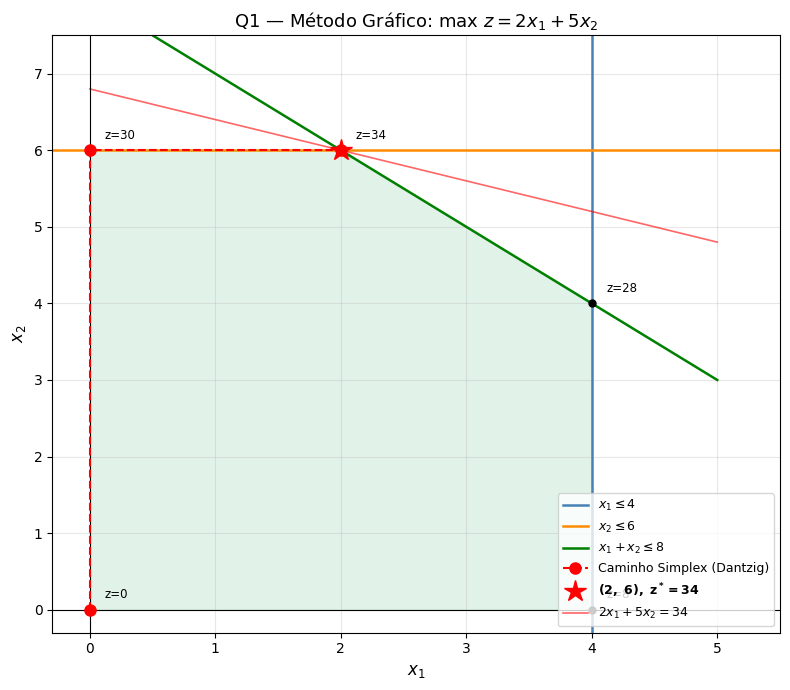

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

x = np.linspace(0, 5, 400)

# Linhas de restricao
ax.axvline(x=4, color='steelblue', linewidth=1.8, label=r'$x_1 \leq 4$')
ax.axhline(y=6, color='darkorange', linewidth=1.8, label=r'$x_2 \leq 6$')
ax.plot(x, 8 - x, color='green', linewidth=1.8, label=r'$x_1 + x_2 \leq 8$')

# Vertices da regiao viavel
vertices = np.array([[0,0],[4,0],[4,4],[2,6],[0,6]])
poligono = Polygon(vertices, closed=True)
colecao = PatchCollection([poligono], alpha=0.15, color='mediumseagreen')
ax.add_collection(colecao)

# Caminho percorrido pelo Simplex (regra de Dantzig)
caminho = np.array([[0,0],[0,6],[2,6]])
ax.plot(caminho[:,0], caminho[:,1], 'r--o', linewidth=1.5,
        markersize=8, label='Caminho Simplex (Dantzig)', zorder=4)

# Valores da FO em cada vertice
valores_fo = {(0,0): 0, (4,0): 8, (4,4): 28, (2,6): 34, (0,6): 30}
for (vx, vy), zv in valores_fo.items():
    ax.plot(vx, vy, 'ko', markersize=5, zorder=3)
    ax.annotate(f'z={zv}', xy=(vx, vy), xytext=(vx+0.12, vy+0.15), fontsize=8.5)

# Ponto otimo
ax.plot(2, 6, 'r*', markersize=16, zorder=5, label=r'$\mathbf{(2,\ 6),\ z^*=34}$')

# Curva de nivel z=34
ax.plot(x, (34 - 2*x)/5, 'r-', linewidth=1.2, alpha=0.6,
        label=r'$2x_1+5x_2=34$')

ax.set_xlim(-0.3, 5.5)
ax.set_ylim(-0.3, 7.5)
ax.set_xlabel(r'$x_1$', fontsize=12)
ax.set_ylabel(r'$x_2$', fontsize=12)
ax.set_title(r'Q1 — Método Gráfico: $\max\ z = 2x_1 + 5x_2$', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

**Comparação Simplex × Método Gráfico:**

| Método | $x_1^*$ | $x_2^*$ | $z^*$ | Iterações |
|--------|---------|---------|-------|----------|
| Simplex (Dantzig) | 2 | 6 | 34 | 2 |
| Método Gráfico | 2 | 6 | 34 | — |

Ambos convergem para a mesma solução ótima. No gráfico, o caminho do Simplex é:

- **Início**: $(0,0)$, $z=0$ (base formada pelas folgas $s_1, s_2, s_3$)
- **Iteração 1** ($x_2$ entra): $(0,6)$, $z=30$ (move ao longo do eixo $x_2$)
- **Iteração 2** ($x_1$ entra): $(2,6)$, $z=34$  **(ótimo)**

---

## 2. Comparação: Exemplo Reddy Mikks (Taha, Seção 3.3.2)

O problema Reddy Mikks na forma padrão (Exemplo 3.3-1 do Taha):

$$\max\ z = 5x_1 + 4x_2$$

$$\text{s.a.}\quad 6x_1+4x_2 \le 24,\quad x_1+2x_2 \le 6,\quad -x_1+x_2 \le 1,\quad x_2 \le 2,\quad x_i \ge 0$$

Com folgas $s_1, \ldots, s_4$:
$$6x_1 + 4x_2 + s_1 = 24,\quad x_1 + 2x_2 + s_2 = 6,\quad -x_1 + x_2 + s_3 = 1,\quad x_2 + s_4 = 2$$

In [16]:
# Colunas: x1, x2, s1, s2, s3, s4
matriz_rm = np.array([
    [ 6, 4, 1, 0, 0, 0],
    [ 1, 2, 0, 1, 0, 0],
    [-1, 1, 0, 0, 1, 0],
    [ 0, 1, 0, 0, 0, 1]
], dtype=float)

vetor_b_rm = np.array([24, 6, 1, 2], dtype=float)
vetor_c_rm = np.array([-5, -4, 0, 0, 0, 0], dtype=float)

resultado_q2 = simplex(matriz_rm, vetor_b_rm, vetor_c_rm)

print('\nSolucao otima (Reddy Mikks):')
print(f'  z* = {resultado_q2[0, -1]:.4f}')

# Identificar valores basicos
linhas_rm, colunas_rm = matriz_rm.shape
for j in range(colunas_rm):
    col = resultado_q2[1:, j]
    if np.sum(col != 0) == 1 and np.isclose(np.max(np.abs(col)), 1):
        linha_basica = np.argmax(np.abs(col)) + 1
        valor = resultado_q2[linha_basica, -1]
        nomes = ['x1','x2','s1','s2','s3','s4']
        if not np.isclose(valor, 0):
            print(f'  {nomes[j]}* = {valor:.4f}')

**************************************************
Tableau Inicial
[[-5. -4.  0.  0.  0.  0.  0.]
 [ 6.  4.  1.  0.  0.  0. 24.]
 [ 1.  2.  0.  1.  0.  0.  6.]
 [-1.  1.  0.  0.  1.  0.  1.]
 [ 0.  1.  0.  0.  0.  1.  2.]]

Iteracao [1] — coluna pivo=0, linha pivo=1
[[ 0.     -0.6667  0.8333  0.      0.      0.     20.    ]
 [ 1.      0.6667  0.1667  0.      0.      0.      4.    ]
 [ 0.      1.3333 -0.1667  1.      0.      0.      2.    ]
 [ 0.      1.6667  0.1667  0.      1.      0.      5.    ]
 [ 0.      1.      0.      0.      0.      1.      2.    ]]

Iteracao [2] — coluna pivo=1, linha pivo=2
[[ 0.     0.     0.75   0.5    0.     0.    21.   ]
 [ 1.     0.     0.25  -0.5    0.     0.     3.   ]
 [ 0.     1.    -0.125  0.75   0.     0.     1.5  ]
 [ 0.     0.     0.375 -1.25   1.     0.     2.5  ]
 [ 0.     0.     0.125 -0.75   0.     1.     0.5  ]]

Nenhum coeficiente negativo na linha z.
******************** FIM ********************

Solucao otima (Reddy Mikks):
  z* = 21.0000


### Comparação com o Taha (p. 43, Exemplo 3.3-1)

| Iteração | Variável que entra | Variável que sai | Razão mínima | $z$ corrente |
|----------|-------------------|------------------|-------------|-------------|
| 1 | $x_1$ (coef. $-5$, mais negativo) | $s_1$ ($24/6 = 4$, mínima) | 4 | 20 |
| 2 | $x_2$ (coef. $-2/3$, único negativo) | $s_2$ ($2 / (4/3) = 1{,}5$, mínima) | 1,5 | **21** |

**Aconteceu algo errado?** Não. Os tableaus gerados pelo algoritmo **coincidem exatamente** com os do Taha. Ambos adotam a regra do coef mais negativo, portanto a sequência de pivôs é idêntica:

1. **Iteração 1**: coeficiente mais negativo é $-5$ ($x_1$). Razão mínima: $24/6=4$ (linha $s_1$). Após o pivô, $x_1=4$ entra na base e $z$ sobe para 20.
2. **Iteração 2**: único coeficiente negativo é $-2/3$ ($x_2$). Razão mínima: $3/2=1{,}5$ (linha $s_2$). Após o pivô, a linha $z$ fica sem negativos: $z^*=21$, $x_1^*=3$, $x_2^*=1{,}5$.

A convergência em 2 iterações com os mesmos pivôs valida a corretude da implementação.

---

## 3. Variante: coeficiente menos negativo

Em vez de escolher o coeficiente **mais negativo** (regra de Dantzig), escolhe-se o coeficiente negativo **mais próximo de zero** (menos negativo) para entrar na base. Por exemplo, entre $-5$ e $-4$, a regra do menos negativo seleciona $-4$.

**Modificação no algoritmo**: substituir `np.argmin` por uma busca que, entre os índices com valor negativo, retorna aquele com maior valor (mais próximo de zero).

> **Dica (Taha):** A regra do mais negativo privilegia a maior taxa de melhoria por iteração. Trocá-la **não compromete a otimalidade**, mas pode aumentar o número de iterações ou alterar o caminho percorrido até a solução ótima.

In [17]:
def simplex_menos_negativo(matriz_A, vetor_b, vetor_c):
    """Simplex com regra do coeficiente menos negativo (mais proximo de zero)."""
    linhas, colunas = matriz_A.shape
    tabela = np.zeros((linhas + 1, colunas + 1), dtype=float)
    tabela[1:linhas + 1, 0:colunas] = matriz_A
    tabela[0, 0:colunas] = vetor_c
    tabela[1:linhas + 1, -1] = vetor_b

    print('*' * 50)
    print('Tableau Inicial')
    print(np.round(tabela, 4))

    iteracao = 1
    while True:
        indices_negativos = np.where(tabela[0, 0:colunas] < 0)[0]
        if len(indices_negativos) == 0:
            print('\nNenhum coeficiente negativo na linha z.')
            print('*' * 20, 'FIM', '*' * 20)
            break

        # Menos negativo = maior valor dentre os negativos (mais proximo de zero)
        coluna_pivo = indices_negativos[np.argmax(tabela[0, indices_negativos])]

        linha_pivo = -1
        menor_razao = float('inf')
        for i in range(1, linhas + 1):
            if tabela[i, coluna_pivo] > 0:
                razao = tabela[i, -1] / tabela[i, coluna_pivo]
                if razao < menor_razao:
                    menor_razao = razao
                    linha_pivo = i

        if linha_pivo == -1:
            print('Problema ilimitado (sem linha pivo valida).')
            break

        tabela[linha_pivo, :] /= tabela[linha_pivo, coluna_pivo]
        for i in range(linhas + 1):
            if i != linha_pivo:
                tabela[i, :] -= tabela[i, coluna_pivo] * tabela[linha_pivo, :]

        print(f'\nIteracao [{iteracao}] — coluna pivo={coluna_pivo} (menos negativo: {tabela[0, coluna_pivo]:.4f}), linha pivo={linha_pivo}')
        print(np.round(tabela, 4))
        iteracao += 1

    return tabela, iteracao - 1

In [18]:
print('=' * 60)
print('Q3 — Regra MENOS NEGATIVO no problema Q1')
print('=' * 60)
resultado_q3, n_iter_q3 = simplex_menos_negativo(
    matriz_A.copy(), vetor_b.copy(), vetor_c.copy()
)
print(f'\nSolucao: z* = {resultado_q3[0, -1]:.2f} | Iteracoes: {n_iter_q3}')
print()
print('=' * 60)
print('Q3 — Regra MAIS NEGATIVO (Dantzig) no mesmo problema')
print('=' * 60)
resultado_dantzig = simplex(matriz_A.copy(), vetor_b.copy(), vetor_c.copy())

Q3 — Regra MENOS NEGATIVO no problema Q1
**************************************************
Tableau Inicial
[[-2. -5.  0.  0.  0.  0.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  1.  0.  0.  1.  8.]]

Iteracao [1] — coluna pivo=0 (menos negativo: 0.0000), linha pivo=1
[[ 0. -5.  2.  0.  0.  8.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 0.  1. -1.  0.  1.  4.]]

Iteracao [2] — coluna pivo=1 (menos negativo: 0.0000), linha pivo=3
[[ 0.  0. -3.  0.  5. 28.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  0.  1.  1. -1.  2.]
 [ 0.  1. -1.  0.  1.  4.]]

Iteracao [3] — coluna pivo=2 (menos negativo: 0.0000), linha pivo=2
[[ 0.  0.  0.  3.  2. 34.]
 [ 1.  0.  0. -1.  1.  2.]
 [ 0.  0.  1.  1. -1.  2.]
 [ 0.  1.  0.  1.  0.  6.]]

Nenhum coeficiente negativo na linha z.
******************** FIM ********************

Solucao: z* = 34.00 | Iteracoes: 3

Q3 — Regra MAIS NEGATIVO (Dantzig) no mesmo problema
**************************************************
Tableau Inicial
[[-2.

### Comparação entre as duas regras (problema Q1)

| Regra | Iterações | $x_1^*$ | $x_2^*$ | $z^*$ | Caminho nos vértices |
|-------|-----------|---------|---------|-------|---------------------|
| Mais negativo (Dantzig) | **2** | 2 | 6 | 34 | $(0,0)\to(0,6)\to(2,6)$ |
| Menos negativo | **3** | 2 | 6 | 34 | $(0,0)\to(4,0)\to(4,4)\to(2,6)$ |

**Análise:**

- **Mesma solução ótima**: ambas as regras convergem para $z^*=34$ com $x_1^*=2$, $x_2^*=6$ — a regra de entrada não compromete a otimalidade.
- **Caminhos diferentes**: Dantzig escolhe $x_2$ (coef. $-5$) primeiro, chegando em 2 iterações. A regra do menos negativo escolhe $x_1$ (coef. $-2$) na 1ª iteração e percorre um vértice extra antes de alcançar o ótimo.
- **Mais iterações**: a regra do menos negativo exigiu 3 iterações contra 2 da Dantzig. Em geral, privilegiar a maior taxa de melhoria por iteração (Dantzig) tende a reduzir o número de pivôs, embora não haja garantia para todos os problemas.

---

## 4. Generalização: maximização ou minimização

### Condição de otimalidade no tableau

Na convenção adotada (linha $z$ com sinais trocados), a condição de otimalidade é:

| Sentido | Linha $z$ no tableau | Condição de parada |
|---------|---------------------|-------------------|
| $\max$ | $z - c^T x = 0$ (coef. $-c_j^{obj}$) | todos $-c_j^{obj} \ge 0$ (nenhum negativo) |
| $\min$ | convertido para $\max(-c^T x)$, linha $z = c^T x$ | idêntica ao caso max |

### Estratégia de implementação

A minimização é convertida em maximização equivalente:

$$\min_{x}\, c^T x \;\equiv\; \max_{x}\, (-c)^T x$$

O tableau do problema $\max(-c)^T x$ tem linha $z$ com coeficientes $-(-c) = c$, ou seja, os **próprios coeficientes originais** do objetivo de minimização. Portanto:

- Para `sentido='max'`: `vetor_c` = coeficientes da função objetivo já com sinal trocado (convenção padrão do tableau).
- Para `sentido='min'`: `vetor_c` = coeficientes **originais** do objetivo de minimização eles coincidem com a convenção do tableau para o `max` equivalente, sem necessidade de negação extra.

Apenas o valor ótimo é negado ao final:

$$z^*_{\min} = -z^*_{\max}$$

In [19]:
def simplex_geral(matriz_A, vetor_b, vetor_c, sentido='max'):
    """
    Simplex generalizado para maximizacao ou minimizacao em forma padrao.

    Para sentido='max': vetor_c com sinal trocado (ex: max 2x1+5x2 => [-2,-5,...]).
    Para sentido='min': vetor_c com coeficientes originais do objetivo de
      minimizacao (ex: min -2x1-5x2 => [-2,-5,...]).
      min c^T x = max (-c)^T x; o tableau de max (-c)^T x usa linha z = c^T x,
      que e exatamente vetor_c — sem necessidade de negacao.
      Apenas z* e negado no final: z*_min = -z*_max.
    """
    vetor_c = np.array(vetor_c, dtype=float)

    if sentido == 'min':
        print('[Minimizacao] min c^T x  ==>  max (-c)^T x')
        print('  vetor_c (= linha z para o max equivalente):', vetor_c)
        print('  Apenas z* sera negado ao final.\n')

    linhas, colunas = matriz_A.shape
    tabela = np.zeros((linhas + 1, colunas + 1), dtype=float)
    tabela[1:linhas + 1, 0:colunas] = matriz_A
    tabela[0, 0:colunas] = vetor_c
    tabela[1:linhas + 1, -1] = vetor_b

    print('*' * 50)
    print('Tableau Inicial')
    print(np.round(tabela, 4))

    iteracao = 1
    while True:
        if not any(tabela[0, 0:colunas] < 0):
            print('\nNenhum coeficiente negativo na linha z.')
            print('*' * 20, 'FIM', '*' * 20)
            break

        coluna_pivo = np.argmin(tabela[0, 0:colunas])
        linha_pivo = -1
        menor_razao = float('inf')
        for i in range(1, linhas + 1):
            if tabela[i, coluna_pivo] > 0:
                razao = tabela[i, -1] / tabela[i, coluna_pivo]
                if razao < menor_razao:
                    menor_razao = razao
                    linha_pivo = i

        if linha_pivo == -1:
            print('Problema ilimitado (sem linha pivo valida).')
            break

        tabela[linha_pivo, :] /= tabela[linha_pivo, coluna_pivo]
        for i in range(linhas + 1):
            if i != linha_pivo:
                tabela[i, :] -= tabela[i, coluna_pivo] * tabela[linha_pivo, :]

        print(f'\nIteracao [{iteracao}] — coluna pivo={coluna_pivo}, linha pivo={linha_pivo}')
        print(np.round(tabela, 4))
        iteracao += 1

    z_max = tabela[0, -1]
    if sentido == 'min':
        z_otimo = -z_max
        print(f'\n[Minimizacao] z_max = {z_max:.4f}  =>  z*_min = -{z_max:.4f} = {z_otimo:.4f}')
    else:
        z_otimo = z_max

    return tabela, z_otimo

### Exemplo de minimização

Reinterpretamos o problema Q1 como **minimização**:

$$\min\ z = -2x_1 - 5x_2$$

$$\text{s.a.}\quad x_1 \le 4,\quad x_2 \le 6,\quad x_1 + x_2 \le 8,\quad x_i \ge 0$$

Os coeficientes do objetivo de minimização são $[-2, -5, 0, 0, 0]$. Passamos esses coeficientes diretamente como `vetor_c` — eles já coincidem com a linha $z$ do max equivalente ($\max\, 2x_1 + 5x_2$).

**Resultado esperado**: $z^*_{\min} = -34$ em $(x_1, x_2) = (2, 6)$, confirmando Q1.

In [20]:
print('=' * 60)
print('Q4 — Minimizacao: min z = -2x1 - 5x2')
print('     (equivalente a max z = 2x1 + 5x2 de Q1)')
print('=' * 60, '\n')

# Coeficientes originais do objetivo de minimizacao
vetor_c_min = np.array([-2, -5, 0, 0, 0], dtype=float)

tabela_q4, z_min = simplex_geral(
    matriz_A.copy(), vetor_b.copy(), vetor_c_min, sentido='min'
)

print(f'\nSolucao otima (minimizacao):')
print(f'  z*_min = {z_min:.2f}')

# Extrair variaveis basicas nao nulas
nomes = ['x1', 'x2', 's1', 's2', 's3']
for j in range(5):
    col = tabela_q4[1:, j]
    if np.sum(np.abs(col) > 1e-9) == 1 and np.isclose(np.max(np.abs(col)), 1.0):
        idx = int(np.argmax(np.abs(col))) + 1
        if not np.isclose(tabela_q4[idx, -1], 0):
            print(f'  {nomes[j]}* = {tabela_q4[idx, -1]:.2f}')

print()
print(f'Verificacao cruzada com Q1:')
print(f'  z*_max(Q1) = {resultado_q1[0,-1]:.2f}')
print(f'  -z*_min    = {-z_min:.2f}')
print(f'  Consistente: {np.isclose(-z_min, resultado_q1[0, -1])}')

Q4 — Minimizacao: min z = -2x1 - 5x2
     (equivalente a max z = 2x1 + 5x2 de Q1)

[Minimizacao] min c^T x  ==>  max (-c)^T x
  vetor_c (= linha z para o max equivalente): [-2. -5.  0.  0.  0.]
  Apenas z* sera negado ao final.

**************************************************
Tableau Inicial
[[-2. -5.  0.  0.  0.  0.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  1.  0.  0.  1.  8.]]

Iteracao [1] — coluna pivo=1, linha pivo=2
[[-2.  0.  0.  5.  0. 30.]
 [ 1.  0.  1.  0.  0.  4.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  0.  0. -1.  1.  2.]]

Iteracao [2] — coluna pivo=0, linha pivo=3
[[ 0.  0.  0.  3.  2. 34.]
 [ 0.  0.  1.  1. -1.  2.]
 [ 0.  1.  0.  1.  0.  6.]
 [ 1.  0.  0. -1.  1.  2.]]

Nenhum coeficiente negativo na linha z.
******************** FIM ********************

[Minimizacao] z_max = 34.0000  =>  z*_min = -34.0000 = -34.0000

Solucao otima (minimizacao):
  z*_min = -34.00
  x1* = 2.00
  x2* = 6.00
  s1* = 2.00

Verificacao cruzada com Q1:
  z*_max(Q1) = 34.00


### Resumo 4.

A estratégia de conversão usa a equivalência:

$$\min\, c^T x \;=\; -\max\, (-c)^T x$$

O tableau do $\max(-c)^T x$ tem linha $z$ igual a $c^T$, que são os próprios coeficientes naturais do objetivo de minimização. Portanto, **não é necessário transformar `vetor_c`** basta negá-lo ao interpretar o resultado final.

**Passos da generalização:**
1. Se `sentido='min'`: usar `vetor_c` (coeficientes originais do min) diretamente no tableau.
2. Executar o Simplex normalmente.
3. Se `sentido='min'`: reportar $z^*_{\min} = -z^*_{\max}$.

**Diferença no fluxograma**: nenhuma mudança nas operações mas apenas a leitura final do resultado é invertida para minimização.

**Limitação**: esta abordagem funciona apenas quando o problema já está em forma padrão com restrições $\le$ e variáveis de folga na base inicial. Para restrições $\ge$ ou $=$, seria necessário o método das **duas fases** ou **Big-M** para construir uma SBV inicial.

---

**Referências:** H. Taha, *Pesquisa Operacional*, 8ª Ed. • [NumPy](https://numpy.org/) • [Matplotlib](https://matplotlib.org/)